In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from random import randint
# import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
# import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
def reduce_data(full_data):

	columns = full_data.columns.values
	bad_cols = []
	maxCount = 0
	emptyCount = 0
	total_non_zero = 0
	for col in columns:
		non_zero = np.count_nonzero(full_data[col].values)
		max = np.max(full_data[col].values)
		if(max < .01 or non_zero < 40):
			total_non_zero += non_zero
			if(max < .001):
				maxCount+=1
			else:
				emptyCount += 1
				
			bad_cols.append(col)

	reduced_data = full_data.drop(labels=bad_cols, axis=1)
	print(reduced_data.shape)

	print(total_non_zero)
	print(maxCount)
	print(emptyCount)

	return reduced_data

In [4]:
def pCA(df, labels):
	pca = PCA(n_components=2)
	data = df.copy()
	# data.drop(labels="sample")
	# print(data["sample"])
	# data = data.drop(labels=["sample"], axis=1)
	print(data.shape)
	print(labels["diagnosis"].shape)
	pca.fit(data)
	x=pca.transform(data)
	plt.figure(figsize=(15,15))

	df_2 = pd.DataFrame()
	df_2["pca-one"] = x[:, 0]
	df_2["pca-two"] = x[:, 1]
	df_2["diagnosis"] = label_encoder.fit_transform(labels["diagnosis"].values)

	sns.scatterplot(x="pca-one", y="pca-two", data=df_2, hue="diagnosis", palette=sns.color_palette("hls", 4))
	plt.xlabel('pc 1')
	plt.ylabel('pc 2')
	plt.legend()
	plt.show()



In [5]:
def umap_func(df, labels):
	data = df.copy()
	results = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(data.values)

	df_2 = pd.DataFrame()
	df_2["umap-n=15-one"] = results[:,0]
	df_2["umap-n=15-two"] = results[:,1]
	df_2["diagnosis"] = label_encoder.fit_transform(labels["diagnosis"].values)


	plt.figure(figsize=(15,15))

	sns.scatterplot(x="umap-n=15-one", y="umap-n=15-two", 
									data=df_2, hue="diagnosis", 
									palette=sns.color_palette("hls", 4))

	plt.show()

In [6]:

data = pd.read_csv('./compiled_data_sorted.csv')
data = data.drop(labels=["sample", "Unnamed: 0.1", "Unnamed: 0", "Homo sapiens"], axis=1)
data = reduce_data(data)

# print(data.head())
y_train_df = pd.read_csv("./diagnosis_sample_sorted.csv")



def custom_aggregation(series):
	# For example, return the range (max - min) of the column
	c_count = 0
	ad_count = 0
	norm_count = 0
	for string in series.values:
		if(string == "Cancer"): c_count += 1
		elif(string == "Large adenoma" or string == "Small adenoma"): ad_count += 1
		elif(string == "Normal"): norm_count += 1

	maximum = np.max([c_count, ad_count, norm_count])
	if(maximum == c_count): return "Cancer"
	elif maximum == ad_count: return "adenoma"
	else: return "Normal"

	if("Cancer" in series.values ): return "Cancer"
	elif("Large adenoma" in series.values): return "adenoma"
	elif("Small adenoma" in series.values): return "adenoma"
	elif ("Normal" in series.values): return "Normal"
	else: return "Normal"



# Use the custom function in groupby aggregation
y_train_df = y_train_df.groupby("sample").agg({
		"sample": lambda x: ", ".join(x.unique()),  # Combine unique names
		"diagnosis": custom_aggregation              # Apply the custom aggregation
})



print("spread", y_train_df.groupby("diagnosis").count())




label_encoder = LabelEncoder()



device = "cuda" if torch.cuda.is_available() else "cpu"


X_train, X_test, y_train, y_test = train_test_split(
		data.values, label_encoder.fit_transform(y_train_df["diagnosis"].values), test_size=0.33, random_state=42)



ros = RandomOverSampler(sampling_strategy='auto')  # 'auto' automatically determines the best ratio for balancing
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

unique, counts = np.unique(y_resampled, return_counts=True)
print(dict(zip(unique, counts)))

y_train_tensor = torch.tensor(y_resampled)

X_train_tensor = torch.tensor(X_resampled, dtype=torch.float32)

X_train_tensor = X_train_tensor.unsqueeze(1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)



# Assuming X_train and y_train are your training features and labels




dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

# Load testing data
y_test_tensor = torch.tensor(y_test)

x_test_tensor = torch.tensor(X_test , dtype=torch.float32)

test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)


(424, 344)
128370
8834
495
spread            sample
diagnosis        
Cancer        230
Normal        133
adenoma        61
{np.int64(0): np.int64(159), np.int64(1): np.int64(159), np.int64(2): np.int64(159)}
torch.Size([477, 1, 344])
torch.Size([477])


/data/mschatz1/bbock4/mambaforge/envs/visualization/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/mschatz1/bbock4/mambaforge/envs/visualization/lib/python3.12/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/data/mschatz1/bbock4/mambaforge/envs/visualization/lib/python3.12/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [7]:
# import umap
# import pandas as pd
# import numpy as np
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# import torch

print(X_train_tensor.shape)

torch.Size([477, 1, 344])


In [8]:
pCA(data, y_train_df)

# umap_func(data,y_train_df)


(424, 344)
(424,)


NameError: name 'sns' is not defined

<Figure size 1500x1500 with 0 Axes>

In [ ]:

class MLP(nn.Module):
	def __init__(self, length):
		# Define layers
		super(MLP, self).__init__()
		self.fc1 = nn.Linear(length, 64)
		self.bn1 = nn.BatchNorm1d(64)
		self.fc2 = nn.Linear(64, 32)
		self.fc3 = nn.Linear(32, 3)    
		
		self.dropout = nn.Dropout(0.2)

	# Model for forward propagation
	def forward(self, x):
		x = torch.relu(self.bn1(self.fc1(x)))
		x = self.dropout(x)  
		x = torch.relu(self.fc2(x))
		x = self.fc3(x)      
		return x


In [ ]:

class convNN(nn.Module):
	def __init__(self):
		super(convNN, self).__init__()
		self.conv1 = nn.Conv1d(16, 32, kernel_size=4)
		self.conv2 = nn.Conv1d(32, 32, kernel_size=7)
		self.max_pool1 = nn.MaxPool1d(kernel_size=2)
		self.conv3 = nn.Conv1d(32, 16, kernel_size=4)
		self.max_pool2 = nn.MaxPool1d(kernel_size=3)
		self.fc1 = nn.Linear(54, 16)
		self.fc2 = nn.Linear(16, 3)

	def forward(self, x):

		# print("pre: " + str(x.shape))      
		x = F.relu(self.conv1(x))  
		# print("post covn1: " + str(x.shape))      

		x = F.relu(self.conv2(x))  
		# print("post conv2: " + str(x.shape))    

		x = self.max_pool1(x)
		# print("post pool 1: " + str(x.shape))      

		x = F.relu(self.conv3(x))  
		# print("post conv 3: " + str(x.shape))      

		x = self.max_pool2(x)  
		# print("post pool2: " + str(x.shape))      
		x = F.relu(self.fc1(x)) 
		# print("post fc1: " + str(x.shape))      

		x = self.fc2(x)       
		# print("post fc2: " + str(x.shape))      
		return x
		

In [ ]:
# class DeepConvNN(nn.Module):
# 		def __init__(self, input_length):
# 				super(DeepConvNN, self).__init__()

# 				# Convolutional layers
# 				self.conv1 = nn.Conv1d(16, 32, kernel_size=4, padding=1)
# 				self.conv2 = nn.Conv1d(32, 64, kernel_size=4, padding=1)
# 				self.max_pool1 = nn.MaxPool1d(kernel_size=2)

# 				self.conv3 = nn.Conv1d(64, 128, kernel_size=4, padding=1)
# 				self.conv4 = nn.Conv1d(128, 128, kernel_size=4, padding=1)
# 				self.max_pool2 = nn.MaxPool1d(kernel_size=2)

# 				self.conv5 = nn.Conv1d(128, 64, kernel_size=4, padding=1)
# 				self.conv6 = nn.Conv1d(64, 32, kernel_size=4, padding=1)
# 				self.max_pool3 = nn.MaxPool1d(kernel_size=2)

# 				# Calculate flattened size
# 				self.flattened_size = self._get_flattened_size(input_length)

# 				# Fully connected layers
# 				self.fc1 = nn.Linear(54, 128)
# 				self.fc2 = nn.Linear(128, 64)
# 				self.fc3 = nn.Linear(64, 3)  # 3 output classes

# 		def _get_flattened_size(self, input_length):
# 				# Simulate passing a dummy input through the convolutional and pooling layers
# 				dummy_input = torch.zeros(1, 16, input_length)
# 				x = F.relu(self.conv1(dummy_input))
# 				x = F.relu(self.conv2(x))
# 				x = self.max_pool1(x)
# 				x = F.relu(self.conv3(x))
# 				x = F.relu(self.conv4(x))
# 				x = self.max_pool2(x)
# 				x = F.relu(self.conv5(x))
# 				x = F.relu(self.conv6(x))
# 				x = self.max_pool3(x)
# 				print(f"Final shape after convolutions and pooling: {x.shape}")
# 				return x.numel()

# 		def forward(self, x):
# 				print(x.shape)
# 				# Convolutional block 1
# 				# x = x[:, :, np.newaxis]
# 				# print(x.shape)
# 				x = F.relu(self.conv1(x))
# 				x = F.relu(self.conv2(x))
# 				x = self.max_pool1(x)

# 				# Convolutional block 2
# 				x = F.relu(self.conv3(x))
# 				x = F.relu(self.conv4(x))
# 				x = self.max_pool2(x)

# 				# Convolutional block 3
# 				x = F.relu(self.conv5(x))
# 				x = F.relu(self.conv6(x))
# 				x = self.max_pool3(x)
# 				print(x.shape)

# 				# Flatten
# 				x = torch.flatten(x, start_dim=1)

# 				# Fully connected layers
# 				x = F.relu(self.fc1(x))
# 				x = F.relu(self.fc2(x))
# 				x = self.fc3(x)

# 				return x
			



In [9]:
import torch
import torch.nn as nn

class DeepConv1DNN(nn.Module):
		def __init__(self, input_length):
				super(DeepConv1DNN, self).__init__()
				self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=4, stride=1, padding=0)
				self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
				self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=4, stride=1, padding=0)
				self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
				self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=4, stride=1, padding=0)
				self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
				self.flatten = nn.Flatten()
				self.fc1 = nn.Linear(128*40, 128)  # Adjusted for the reduced input size after pooling
				self.fc2 = nn.Linear(128, 32)
				self.output_layer = nn.Linear(32, 3)  # Adjust the output layer based on your number of classes

		def forward(self, x):
				# print(x.shape)
				x = self.conv1(x)
				# print(x.shape)
				x = self.pool1(x)
				# print(x.shape)
				x = self.conv2(x)
				# print(x.shape)
				x = self.pool2(x)
				# print(x.shape)
				x = self.conv3(x)
				# print(x.shape)
				x = self.pool3(x)
				# print(x.shape)
				x = self.flatten(x)
				# print(x.shape)
				x = self.fc1(x)
				x = nn.ReLU()(x)
				x = self.fc2(x)
				x = nn.ReLU()(x)
				return self.output_layer(x)



# To use the model, define an optimizer and a loss function, and then train the model as needed.


In [10]:


def train_model(model):
	model = model
	# Define the loss function
	criterion = nn.CrossEntropyLoss()  
	# Define the optimizer
	optimizer = optim.Adam(model.parameters(), lr=0.001)


	num_epochs = 80

	# Holds average training loss per epoch
	training_loss_per_epoch = []
	testing_loss_per_epoch = []

	for epoch in range(num_epochs):
		# Set the model into training mode
		model.train()  
		running_loss = 0.0
		num_batches = 0
		num_test_batches = 0
		test_running_loss = 0
		# Stochastic gradient descent on each batch 
		for batch_X, batch_y in dataloader:
			# Zero gradients
			optimizer.zero_grad()
			# Forward pass 
			# batch_X = batch_X[:, :, np.newaxis]
			# print("before", batch_X.shape)
			output = model(batch_X)
			# print(output.shape)
			# print(batch_X.shape)
			# print(batch_y.shape)
			# Compute loss for current batch
			loss = criterion(output, batch_y)
			# Backpropagation
			loss.backward()
			# Update model parameters 
			optimizer.step()

			# Keep track of loss for each batch
			running_loss += loss.item()
			num_batches += 1


		with torch.no_grad():      
			for test_batch_X, test_batch_y in test_dataloader:
				# Forward pass on the entire test set
				# test_batch_X = test_batch_X[:, :, np.newaxis]
				# print("before", test_batch_X.shape)
				output_test = model(test_batch_X)
				# Compute loss on the entire test set
				avg_test_loss = criterion(output_test, test_batch_y).item()
				test_running_loss += avg_test_loss
				num_test_batches += 1

		# Calculate average loss per epoch
		avg_loss = running_loss / num_batches
		training_loss_per_epoch.append(avg_loss)
		testing_loss_per_epoch.append(test_running_loss/num_test_batches)


		# Print epoch and training loss
		print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {loss:.6f}')
		model_save_path = f'/data/mschatz1/bbock4/models/DCNN/model_epoch_{epoch}.pth'
		torch.save(model.state_dict(), model_save_path)
		# print(f'Epoch {epoch+1}/{num_epochs}, test Loss: {loss:.6f}')

	print(training_loss_per_epoch)
	print(testing_loss_per_epoch)

	plt.scatter((range(1,len(training_loss_per_epoch)+1)), training_loss_per_epoch, label = "training")
	plt.scatter((range(1,len(testing_loss_per_epoch)+1)), testing_loss_per_epoch, label = "testing")

	plt.xlabel("Number of Epochs")
	plt.ylabel("Train Loss")
	plt.title("Train Loss Against Number of Epochs")
	plt.legend()
	return model


Epoch 1/80, Train Loss: 1.160317
Epoch 2/80, Train Loss: 1.099317
Epoch 3/80, Train Loss: 1.094758
Epoch 4/80, Train Loss: 1.097968
Epoch 5/80, Train Loss: 1.104678
Epoch 6/80, Train Loss: 1.106033
Epoch 7/80, Train Loss: 1.100826
Epoch 8/80, Train Loss: 1.100233
Epoch 9/80, Train Loss: 1.104311
Epoch 10/80, Train Loss: 1.102255
Epoch 11/80, Train Loss: 1.098781
Epoch 12/80, Train Loss: 1.103780
Epoch 13/80, Train Loss: 1.109563
Epoch 14/80, Train Loss: 1.096524
Epoch 15/80, Train Loss: 1.097129
Epoch 16/80, Train Loss: 1.098553
Epoch 17/80, Train Loss: 1.097103
Epoch 18/80, Train Loss: 1.099879
Epoch 19/80, Train Loss: 1.099888
Epoch 20/80, Train Loss: 1.051347
Epoch 21/80, Train Loss: 0.987550
Epoch 22/80, Train Loss: 1.022786
Epoch 23/80, Train Loss: 0.967506
Epoch 24/80, Train Loss: 0.975336
Epoch 25/80, Train Loss: 0.991073
Epoch 26/80, Train Loss: 0.840330
Epoch 27/80, Train Loss: 0.778366
Epoch 28/80, Train Loss: 0.683616
Epoch 29/80, Train Loss: 0.790360
Epoch 30/80, Train Loss

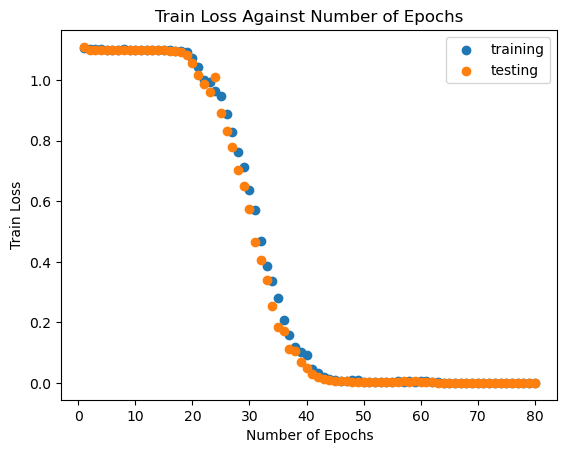

In [15]:
# convNN, DeepConvNN, MLP

model = train_model(DeepConv1DNN(344))
# model = train_CNN()
predicted_labels = []
true_labels = []

with torch.no_grad():
	for batch_X, batch_y in test_dataloader:
		model.eval()
		# batch_X = batch_X[:, :, np.newaxis]
		# print(batch_X.shape)
		output = model(batch_X)

		_, tmp_predicted_labels = torch.max(output, 1)  
		predicted_labels.append(tmp_predicted_labels)
		true_labels.append(batch_y)
	
	# true_labels = y_test



report = classification_report(torch.cat(true_labels), torch.cat(predicted_labels), target_names=label_encoder.classes_)
print(report)

In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV



param_grid_rf = {
		'n_estimators': [50, 100, 200]
}
model_rf = RandomForestClassifier()
grid_search_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid_rf, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
pd.DataFrame(grid_search_rf.cv_results_)[['params', 'mean_test_score']]
preds = grid_search_rf.best_estimator_.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.51      0.92      0.66        71
           1       0.42      0.10      0.16        50
           2       1.00      0.05      0.10        19

    accuracy                           0.51       140
   macro avg       0.64      0.36      0.31       140
weighted avg       0.54      0.51      0.40       140



In [138]:
from sklearn.svm import SVC
param_grid_svc = {
		'kernel': ['linear', 'poly', 'rbf']
}

svc = SVC()
grid_search_svc = GridSearchCV(estimator=svc, param_grid=param_grid_svc, scoring='accuracy')
grid_search_svc.fit(X_train, y_train)
pd.DataFrame(grid_search_svc.cv_results_)[['params', 'mean_test_score']]


preds = grid_search_svc.best_estimator_.predict(X_test)

print(classification_report(y_test, preds))



              precision    recall  f1-score   support

           0       0.51      1.00      0.67        71
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00        19

    accuracy                           0.51       140
   macro avg       0.17      0.33      0.22       140
weighted avg       0.26      0.51      0.34       140



/data/mschatz1/bbock4/mambaforge/envs/comp_gen_final/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/mschatz1/bbock4/mambaforge/envs/comp_gen_final/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/mschatz1/bbock4/mambaforge/envs/comp_gen_final/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

In [ ]:
import torch
import cv2

def generate_grad_cam(model, input_image, target_layer):
	print("start")
	input_image.requires_grad = True
	output = model(input_image)
	print("starting backwards")
	
	# Backward pass to compute gradients
	output.backward(torch.ones_like(output))
	print("doing gradients")
	gradients = target_layer[0].grad.data  # Get the gradient of the output w.r.t. the activation of the target layer
	weights = torch.mean(gradients, dim=[2])  # Global average pooling
	grad_cam = torch.matmul(weights, target_layer[0])
	grad_cam = torch.relu(grad_cam)  # ReLU to remove negative values
	print("done")
	return grad_cam


checkpoint_path = '/data/mschatz1/bbock4/models/DCNN/model_epoch_42.pth'

model = DeepConv1DNN(344)
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.eval()


# model = DeepConv1DNN(344)
# model = model.load_state_dict(torch.load(checkpoint_path))
# print(model_state_dict.keys())


for batch_X, _ in dataloader:
	grad_cam = generate_grad_cam(model, batch_X, model.conv1)
	for i in range(len(batch_X)):
		print(i)
		grad_cam_resized = cv2.resize(grad_cam.numpy(), (344, 1), interpolation=cv2.INTER_LINEAR)  # Adjust dimensions for plotting
		# Plotting the Grad-CAM heatmap
		plt.imshow(grad_cam_resized, cmap='hot', aspect='auto')
		plt.colorbar()
		plt.title(f'Grad-CAM for Sample {i}')
		plt.show()
		print("done with ", i)
		break
	print("done with inner")
	break

start
starting backwards


In [1]:
def generate_saliency_map(model, input_image):
		input_image.requires_grad = True
		output = model(input_image)
		
		saliency_maps = []
		
		# Iterate over each sample in the batch
		for i in range(len(output)):
				model.zero_grad()
				target_class = output[i].argmax()
				output[i, target_class].backward(retain_graph=True)
				
				# Compute the saliency map (absolute gradients)
				saliency, _ = torch.max(input_image.grad.data.abs()[i], dim=0)
				saliency_maps.append(saliency.cpu().numpy())
		
		return saliency_maps

# Example usage with a batch of inputs:
checkpoint_path = '/data/mschatz1/bbock4/models/DCNN/model_epoch_42.pth'

model = DeepConv1DNN(344)
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.eval()
saliency_maps = []

# Process each batch in the DataLoader
for batch_X, _ in dataloader:
		batch_saliency_maps = generate_saliency_map(model, batch_X)
		saliency_maps.extend(batch_saliency_maps)

# model.eval()  # Set the model to evaluation mode
# saliency_map = generate_saliency_map(model, batch_X)
plt.plot(saliency_maps[0], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

NameError: name 'DeepConv1DNN' is not defined

In [ ]:
def train_MLP():
	model = MLP()
	# Define the loss function
	criterion = nn.CrossEntropyLoss()  
	# Define the optimizer
	optimizer = optim.Adam(model.parameters(), lr=0.001)


	num_epochs = 60

	# Holds average training loss per epoch
	training_loss_per_epoch = []
	testing_loss_per_epoch = []

	for epoch in range(num_epochs):
		# Set the model into training mode
		model.train()  
		running_loss = 0.0
		num_batches = 0
		num_test_batches = 0
		test_running_loss = 0
		# Stochastic gradient descent on each batch 
		for batch_X, batch_y in dataloader:
			# Zero gradients
			optimizer.zero_grad()
			# Forward pass 
			output = model(batch_X)
			# print(output.shape)
			# print(batch_X.shape)
			# print(batch_y.shape)
			# Compute loss for current batch
			loss = criterion(output, batch_y)
			# Backpropagation
			loss.backward()
			# Update model parameters 
			optimizer.step()

			# Keep track of loss for each batch
			running_loss += loss.item()
			num_batches += 1


		with torch.no_grad():      
			for test_batch_X, test_batch_y in test_dataloader:
				# Forward pass on the entire test set
				output_test = model(test_batch_X)
				# Compute loss on the entire test set
				avg_test_loss = criterion(output_test, test_batch_y).item()
				test_running_loss += avg_test_loss
				num_test_batches += 1

		# Calculate average loss per epoch
		avg_loss = running_loss / num_batches
		training_loss_per_epoch.append(avg_loss)
		testing_loss_per_epoch.append(test_running_loss/num_test_batches)


		# Print epoch and training loss
		print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {loss:.6f}')
		# print(f'Epoch {epoch+1}/{num_epochs}, test Loss: {loss:.6f}')

	print(training_loss_per_epoch)
	# print(testing_loss_per_epoch)

	plt.scatter((range(1,len(training_loss_per_epoch)+1)), training_loss_per_epoch, label = "training")
	plt.scatter((range(1,len(testing_loss_per_epoch)+1)), testing_loss_per_epoch, label = "testing")

	plt.xlabel("Number of Epochs")
	plt.ylabel("Train Loss")
	plt.title("Train Loss Against Number of Epochs")
	plt.legend()
	plt.show()
	return model